<a href="https://colab.research.google.com/github/swathivenkatesan87/24ADI003-24BAD122-ML/blob/main/EXP_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

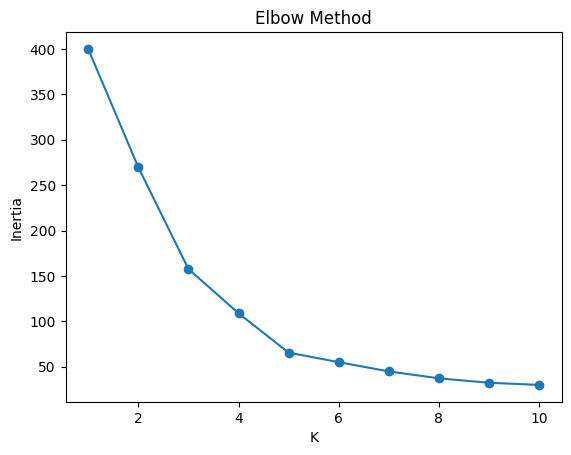

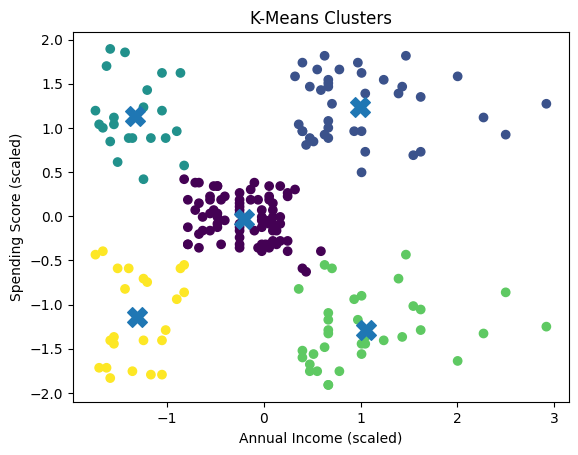

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043
Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


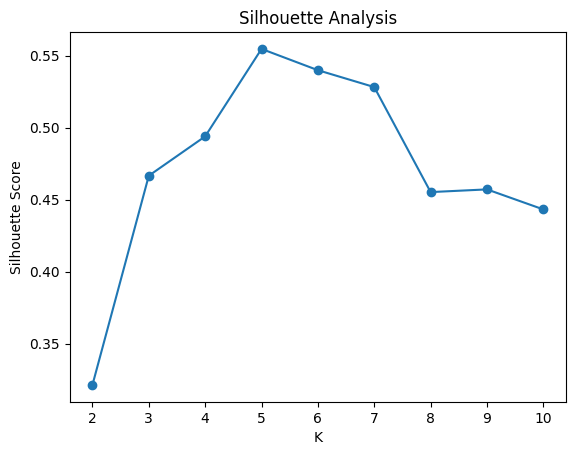

In [ ]:
#SWATHI 24BAD122
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method to find optimal K
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Apply K-Means
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Assign cluster labels
df['Cluster'] = clusters

# Plot clusters with centroids
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200)
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('K-Means Clusters')
plt.show()

# Cluster analysis
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

# Evaluation metrics
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

# Silhouette score for different K
silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Silhouette Scores
plt.figure()
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

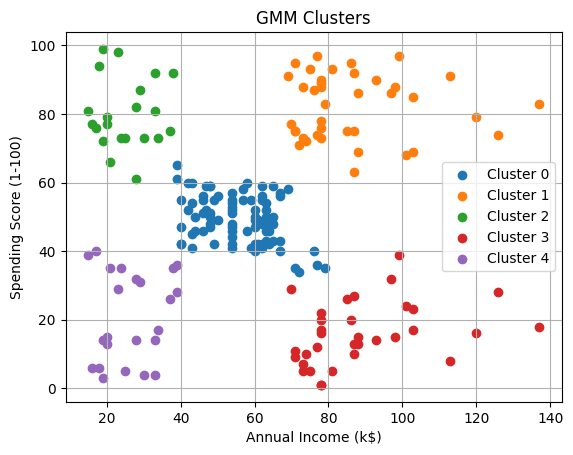

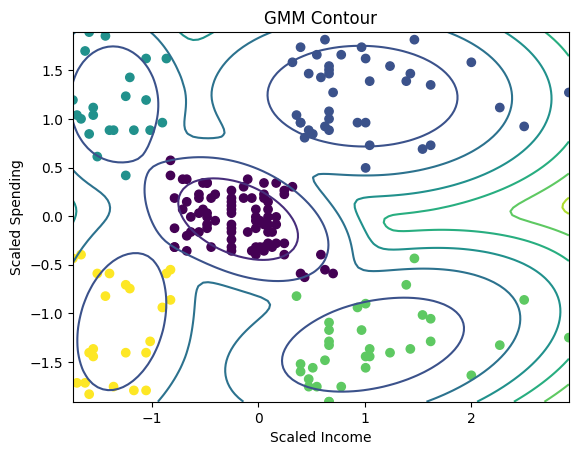

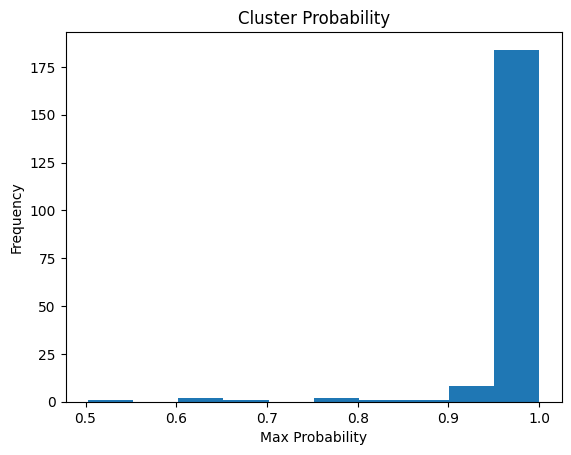

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


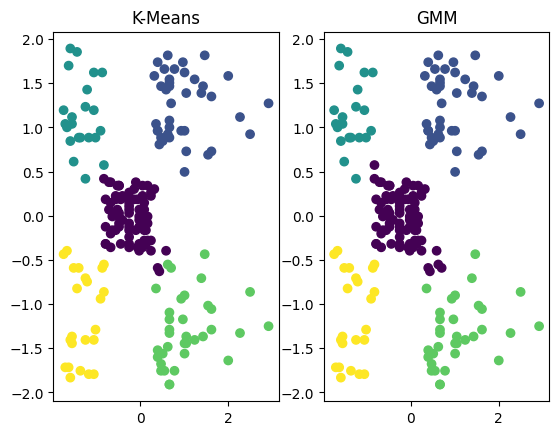

             Annual Income (k$)  Spending Score (1-100)
GMM_Cluster                                            
0                     55.642857               49.369048
1                     86.538462               82.128205
2                     25.095238               80.047619
3                     88.818182               16.000000
4                     26.304348               20.913043


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply GMM
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

# Predict probabilities and clusters
probs = gmm.predict_proba(X_scaled)
gmm_labels = np.argmax(probs, axis=1)
df['GMM_Cluster'] = gmm_labels

# Plot GMM clusters
plt.figure()
for i in range(5):
    plt.scatter(
        df[df['GMM_Cluster'] == i]['Annual Income (k$)'],
        df[df['GMM_Cluster'] == i]['Spending Score (1-100)'],
        label=f'Cluster {i}'
    )
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('GMM Clusters')
plt.legend()
plt.grid(True)
plt.show()

# GMM contour plot
x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 100)
y = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)
grid = np.c_[X_grid.ravel(), Y_grid.ravel()]

Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels)
plt.xlabel('Scaled Income')
plt.ylabel('Scaled Spending')
plt.title('GMM Contour')
plt.show()

# Probability distribution
plt.figure()
plt.hist(probs.max(axis=1), bins=10)
plt.xlabel('Max Probability')
plt.ylabel('Frequency')
plt.title('Cluster Probability')
plt.show()

# Evaluation metrics
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, gmm_labels))

# K-Means for comparison
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Comparison plot
plt.figure()
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title('K-Means')

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels)
plt.title('GMM')
plt.show()
# Cluster analysis
print(df.groupby('GMM_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())